Explained Variance by Component: [0.49279371 0.21902999 0.14057888 0.09094668 0.04390732 0.01274342]
Cumulative Explained Variance: [0.49279371 0.7118237  0.85240257 0.94334926 0.98725658 1.        ]


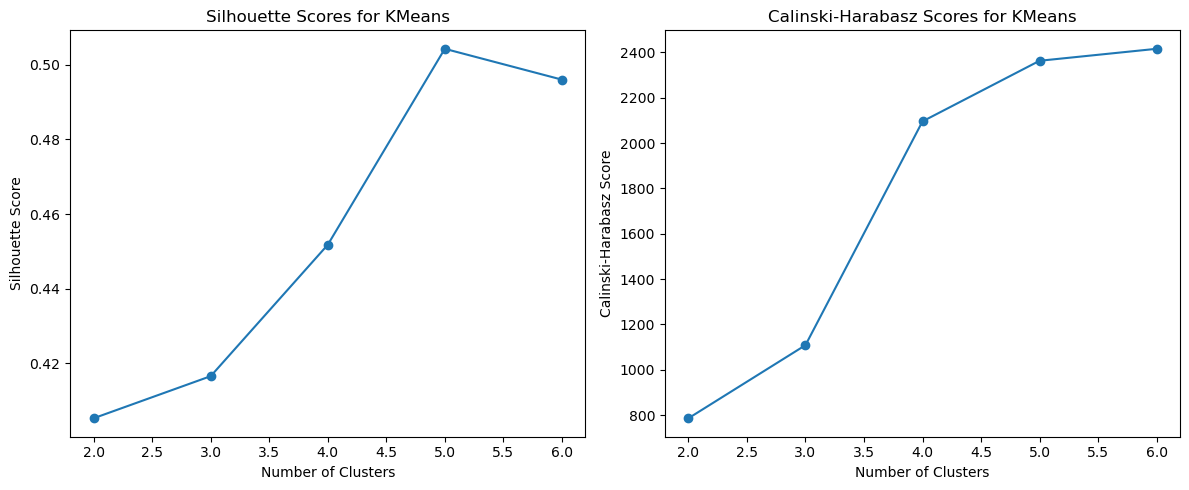

KMeans Cluster Profiles:
                Frequency  MonetaryValue  TotalQuantity  UniqueProducts  \
KMeans_Cluster                                                            
0                5.275284    2536.820140    1479.522440       75.515487   
1                1.568259     545.437612     282.756826       23.768771   
2                1.500000  122828.050000   77606.000000        2.000000   

                   Recency  AvgOrderValue  DBSCAN_Cluster  
KMeans_Cluster                                             
0                37.731669     399.595705       -0.056258  
1               236.669795     334.985241       -0.016212  
2               162.500000   80709.925000       -1.000000  


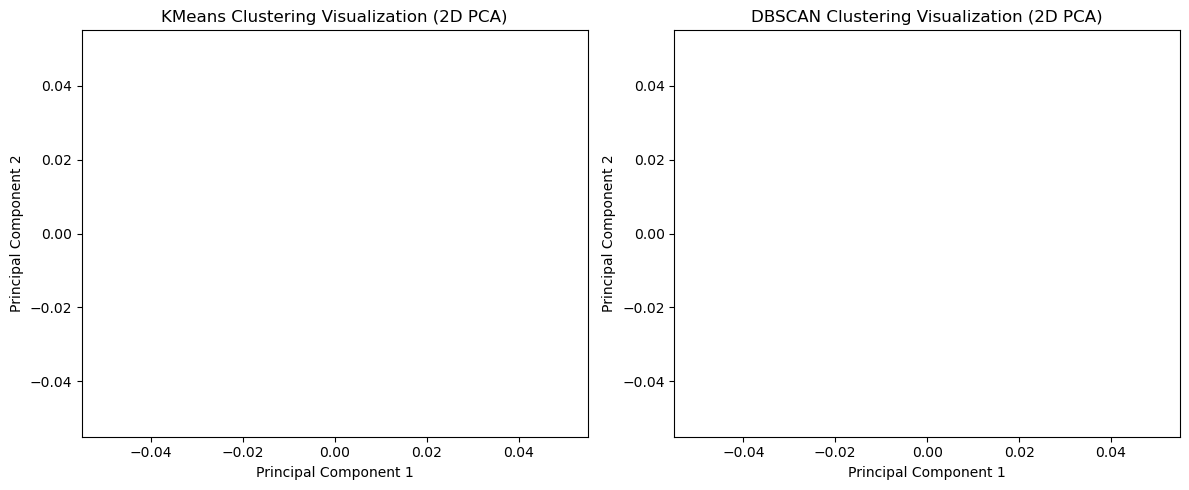

In [ ]:
import pandas as pd #Импортируем библиотеку Pandas и задаем короткое имя pd для работы с таблицами.
import numpy as np #Импортируем библиотеку NumPy для работы с массивами и матрицами.
from sklearn.preprocessing import StandardScaler #Импортируем класс StandardScaler из библиотеки sklearn для стандартизации данных.
from sklearn.decomposition import PCA #Импортируем PCA (анализ главных компонент) для снижения размерности данных.
from sklearn.cluster import KMeans, DBSCAN #Импортируем алгоритмы кластеризации KMeans и DBSCAN.
from sklearn.metrics import silhouette_score, calinski_harabasz_score #Импортируем метрики кластеризации: силуэтный коэффициент и коэффициент Calinski-Harabasz.
import matplotlib.pyplot as plt #Импортируем библиотеку Matplotlib для построения графиков.


# Загрузка данных
file_path = r'D:\AI_Engineer\homework_3\Online Retail.xlsx'  # Укажите путь к вашему файлу
data = pd.read_excel(file_path, sheet_name='Online Retail')

#data =: Переменная, куда загружаются данные. pd.read_excel: Функция из библиотеки Pandas для чтения Excel-файлов. file_path: Путь к файлу, который мы указали ранее. sheet_name='Online Retail': Указывает, что нужно загрузить лист с именем Online Retail.

# Предобработка данных
data = data.dropna()  # Удаляем строки с отсутствующими значениями
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]  # Удаляем строки с отрицательными значениями. 
#data['Quantity']: Доступ к колонке Quantity (количество товара).
#data['UnitPrice']: Доступ к колонке UnitPrice (цена за единицу товара).
#data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]: Оставляем только строки, где количество и цена больше 0.


data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])  # Преобразуем дату

#data['InvoiceDate']: Обращение к колонке InvoiceDate (дата счета).
#pd.to_datetime: Преобразование данных в формат datetime для работы с датами.

# Создание признаков на уровне клиента
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']  # Расчет общей стоимости
#data['TotalPrice']: Создаем новую колонку TotalPrice.
#data['Quantity'] * data['UnitPrice']: Умножаем количество товара на цену, чтобы получить общую стоимость.


customer_data = data.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',           # Частота транзакций
    'TotalPrice': 'sum',              # Общая сумма покупок
    'InvoiceDate': 'max',             # Дата последней покупки
    'Quantity': 'sum',                # Общее количество товаров
    'StockCode': 'nunique'            # Количество уникальных товаров
}).rename(columns={
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'MonetaryValue',
    'InvoiceDate': 'LastPurchaseDate',
    'Quantity': 'TotalQuantity',
    'StockCode': 'UniqueProducts'
})

#data.groupby('CustomerID'): Группируем данные по ID клиента.
#.agg: Применяем несколько функций агрегации к каждой группе.
#'InvoiceNo': 'nunique': Считаем уникальные транзакции для каждого клиента.
#'TotalPrice': 'sum': Суммируем общую стоимость покупок.
#'InvoiceDate': 'max': Находим последнюю дату покупки.
#'Quantity': 'sum': Суммируем общее количество купленных товаров.
#'StockCode': 'nunique': Считаем количество уникальных продуктов.


# Расчет давности (Recency) и средней стоимости заказа
latest_date = data['InvoiceDate'].max()
customer_data['Recency'] = (latest_date - customer_data['LastPurchaseDate']).dt.days

#latest_date: Последняя дата в данных.
#customer_data['LastPurchaseDate']: Последняя покупка клиента.
#.dt.days: Вычисляем разницу в днях.

customer_data.drop(columns=['LastPurchaseDate'], inplace=True)
customer_data['AvgOrderValue'] = customer_data['MonetaryValue'] / customer_data['Frequency']

# Стандартизация данных перед PCA
features = customer_data[['Frequency', 'MonetaryValue', 'Recency', 'TotalQuantity', 'UniqueProducts', 'AvgOrderValue']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

#scaler = StandardScaler(): Создаем объект стандартизатора.
#.fit_transform(features): Применяем стандартизацию ко всем признакам.

# Реализация PCA
pca = PCA(n_components=6)
pca_components = pca.fit_transform(scaled_features)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

#pca = PCA(n_components=6): Создаем объект PCA для 6 компонент.
#.fit_transform(scaled_features): Применяем PCA к стандартизированным данным.
#pca.explained_variance_ratio_: Это массив, показывающий долю дисперсии, объясняемой каждой главной компонентой.
#np.cumsum(explained_variance): Вычисляет кумулятивную (накопленную) дисперсию, которая показывает, сколько общей информации объясняется при добавлении каждой последующей компоненты.

# Вывод кумулятивной объясненной дисперсии
print("Explained Variance by Component:", explained_variance)
print("Cumulative Explained Variance:", cumulative_variance)

# Определение оптимального количества кластеров
silhouette_scores = []
calinski_harabasz_scores = []
cluster_range = range(2, 7)

#silhouette_score: Метрика, измеряющая, насколько плотны и разделены кластеры (чем выше, тем лучше).
#calinski_harabasz_score: Метрика, которая измеряет дисперсию между и внутри кластеров (чем выше, тем лучше).

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    silhouette_scores.append(silhouette_score(scaled_features, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(scaled_features, labels))
    
#kmeans = KMeans(n_clusters=3): Создаем объект K-средних для 3 кластеров.
#.fit_predict: Применяем алгоритм и добавляем метки кластеров.

# Визуализация коэффициентов силуэта и Calinski-Harabasz
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.title("Silhouette Scores for KMeans")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.subplot(1, 2, 2)
plt.plot(cluster_range, calinski_harabasz_scores, marker='o')
plt.title("Calinski-Harabasz Scores for KMeans")
plt.xlabel("Number of Clusters")
plt.ylabel("Calinski-Harabasz Score")

plt.tight_layout()
plt.show()

# Кластеризация с K-средними и DBSCAN
optimal_k = 3  # Оптимальное количество кластеров на основе предыдущего анализа
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
customer_data['KMeans_Cluster'] = kmeans.fit_predict(scaled_features)

dbscan = DBSCAN(eps=0.5, min_samples=5) #Определяют радиус для кластера и минимальное количество точек в кластере соответственно.
customer_data['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_features)

#dbscan = DBSCAN(eps=0.5, min_samples=5): Создаем объект DBSCAN с заданными параметрами.
#.fit_predict: Применяем алгоритм и добавляем метки кластеров.

# Профилирование кластеров (для KMeans)
kmeans_profiles = customer_data.groupby('KMeans_Cluster').mean()
#customer_data.groupby('KMeans_Cluster').mean(): Группируем данные по кластерам и считаем средние значения признаков для каждого кластера. Это позволяет нам понять, чем отличаются кластеры по средним значениям.

print("KMeans Cluster Profiles:")
print(kmeans_profiles)

# Визуализация кластеров по первым двум компонентам PCA
pca_2d = PCA(n_components=2).fit_transform(scaled_features)
pca_df = pd.DataFrame(pca_2d, columns=['PC1', 'PC2'])
pca_df['KMeans_Cluster'] = customer_data['KMeans_Cluster']
pca_df['DBSCAN_Cluster'] = customer_data['DBSCAN_Cluster']

plt.figure(figsize=(12, 5))

# Визуализация кластеров KMeans
plt.subplot(1, 2, 1)
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['KMeans_Cluster'], cmap='viridis', s=50, alpha=0.7)
plt.title("KMeans Clustering Visualization (2D PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

#plt.scatter: Создаем точечный график.
#c=pca_df['KMeans_Cluster']: Цвет точек зависит от кластеров.
#cmap='viridis': Цветовая схема.
#alpha=0.7: Прозрачность точек.


# Визуализация кластеров DBSCAN
plt.subplot(1, 2, 2)
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['DBSCAN_Cluster'], cmap='viridis', s=50, alpha=0.7)
plt.title("DBSCAN Clustering Visualization (2D PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")


plt.tight_layout()
#Используется для того, чтобы графики не накладывались друг на друга, автоматически регулируя отступы.
plt.show()
